# IQR 이상치 제거 유무 비교 (2026-08-28)

context_length 스윕 결론대로 **blaine=1024 / residue=1536**, prediction_length=4, full fine-tuning
으로 고정하고, 학습 데이터만 두 갈래로 나눠서 비교합니다.

- **with_iqr**  : `data/processed/with_iqr/quality_timeseries.csv` — `remove_iqr_outliers()`로 호기별·컬럼별 `[Q1-1.5·IQR, Q3+1.5·IQR]` 밖의 값을 NaN 처리 (타깃 포함)
- **without_iqr**: `data/processed/without_iqr/quality_timeseries.csv` — 그 단계만 건너뜀 (`clean()`의 고정 임계값 규칙은 양쪽 다 적용)

학습 하이퍼파라미터는 `run_ctx_sweep_v2.sh`와 100% 동일 (1000 steps / lr 1e-6 / batch 64). 두 arm의
유일한 차이는 입력 CSV뿐 → IQR 효과만 분리됩니다. 실행: `train/run_iqr_experiment.sh`.

## 평가 설계 — 두 테스트셋 모두에서 backtest
두 모델을 **같은** 테스트셋에서 평가해야 공정 비교(naive baseline / skill-score 분모도 동일)가 됩니다.
그래서 4개 모델을 각각 두 테스트셋에서 backtest했습니다:

| 테스트셋 | 뜻 | 성격 |
|---|---|---|
| **raw** (`without_iqr` test) | 실측 그대로, 극단값 포함 | 배포 현실 — 운영 중엔 들어오는 데이터에서 이상치를 뺄 수 없음. **주 지표** |
| **clean** (`with_iqr` test) | IQR로 극단값이 제거된 정상운전 구간 | "정상 조업" 성능 |

IQR 학습이 raw에서 크게 지면 정제된 분포에 과적합된 것(취약). raw·clean 둘 다에서 이기거나 비기면
IQR 제거가 안전하고 도움이 된다는 뜻.

이 노트북은 GPU를 쓰지 않습니다 — 저장된 CSV만 읽습니다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
while not (ROOT / 'config.py').exists():
    if ROOT.parent == ROOT:
        raise RuntimeError('config.py를 못 찾음 — chronos_quality_net 폴더(또는 그 하위)에서 실행하세요.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import config as cfg
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score

EVAL_DIR = ROOT / 'eval'
TARGETS = cfg.TARGET_COLS
CTX = {'blaine': 1024, 'residue': 1536}
TRAIN_VARIANTS = ['withiqr', 'withoutiqr']
EVAL_SETS = ['raw', 'clean']
VARIANT_LABEL = {'withiqr': 'IQR 제거', 'withoutiqr': 'IQR 미제거'}
VARIANT_COLOR = {'withiqr': 'tab:green', 'withoutiqr': 'tab:red'}

WITH_IQR_CSV = ROOT / 'data' / 'processed' / 'with_iqr' / 'quality_timeseries.csv'
WITHOUT_IQR_CSV = ROOT / 'data' / 'processed' / 'without_iqr' / 'quality_timeseries.csv'
print('targets:', TARGETS, ' ctx:', CTX)

targets: ['blaine', 'residue']  ctx: {'blaine': 1024, 'residue': 1536}


## 1. 데이터 레벨 — IQR이 뭘 얼마나 제거했나

`without_iqr`엔 값이 있는데 `with_iqr`에선 NaN인 셀 = IQR이 이상치로 판정해 버린 값.

IQR로 NaN 처리된 셀: 117,672 / 4,035,876 (2.92%)
  blaine: 실측 40,681 -> 39,759  (IQR 제거 922, 2.3%)
  residue: 실측 40,738 -> 39,782  (IQR 제거 956, 2.3%)


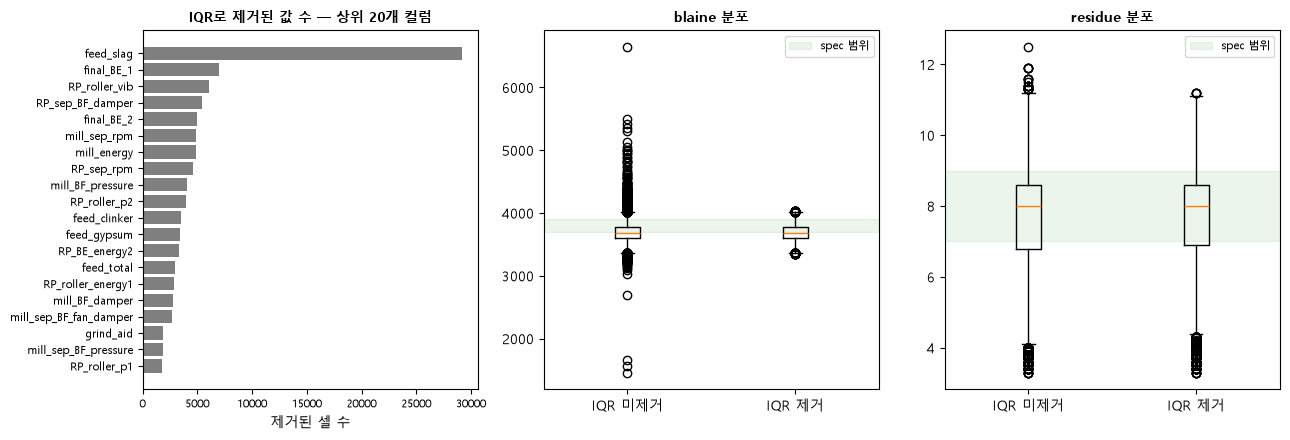

In [2]:
df_with = pd.read_csv(WITH_IQR_CSV, parse_dates=['timestamp'])
df_without = pd.read_csv(WITHOUT_IQR_CSV, parse_dates=['timestamp'])
assert df_with.shape == df_without.shape and list(df_with.columns) == list(df_without.columns)

feature_cols = cfg.CONTROL_COLS + cfg.MONITOR_COLS + cfg.TARGET_COLS
removed = pd.Series({c: int((df_without[c].notna() & df_with[c].isna()).sum()) for c in feature_cols})
removed = removed.sort_values(ascending=False)
total_cells = int(df_without[feature_cols].notna().sum().sum())
print(f'IQR로 NaN 처리된 셀: {removed.sum():,} / {total_cells:,} ({removed.sum() / total_cells * 100:.2f}%)')
for t in TARGETS:
    n0, n1 = int(df_without[t].notna().sum()), int(df_with[t].notna().sum())
    print(f'  {t}: 실측 {n0:,} -> {n1:,}  (IQR 제거 {n0 - n1:,}, {(n0 - n1) / n0 * 100:.1f}%)')

fig, axes = plt.subplots(1, 1 + len(TARGETS), figsize=(6 + 3.5 * len(TARGETS), 4.5))
top = removed[removed > 0].head(20)
axes[0].barh(top.index[::-1], top.values[::-1], color='tab:gray')
axes[0].set_title('IQR로 제거된 값 수 — 상위 20개 컬럼', fontsize=10, fontweight='bold')
axes[0].set_xlabel('제거된 셀 수')
axes[0].tick_params(labelsize=8)

for ax, t in zip(axes[1:], TARGETS):
    ax.boxplot([df_without[t].dropna(), df_with[t].dropna()], tick_labels=['IQR 미제거', 'IQR 제거'])
    lo, hi = cfg.SPEC_RANGES[t]
    ax.axhspan(lo, hi, color='green', alpha=0.08, label='spec 범위')
    ax.set_title(f'{t} 분포', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. 백테스트 결과 로딩 (4 모델 x 2 테스트셋 = 8개)

In [3]:
def backtest_path(target, trainvar, evalvar):
    return EVAL_DIR / f'backtest_{target}_{trainvar}_evalon_{evalvar}.csv'

bt = {}
missing = []
for target in TARGETS:
    for tv in TRAIN_VARIANTS:
        for ev in EVAL_SETS:
            p = backtest_path(target, tv, ev)
            if p.exists():
                bt[(target, tv, ev)] = pd.read_csv(p, parse_dates=['timestamp'])
            else:
                missing.append(p.name)
if missing:
    print('[missing]', len(missing), 'files — train/run_iqr_experiment.sh 아직 안 끝났을 수 있음:')
    for m in missing:
        print(' ', m)
else:
    print('8개 backtest 전부 로딩 완료')
    for k, v in bt.items():
        print(f'  {k}: n={len(v)}')

8개 backtest 전부 로딩 완료
  ('blaine', 'withiqr', 'raw'): n=1035
  ('blaine', 'withiqr', 'clean'): n=1007
  ('blaine', 'withoutiqr', 'raw'): n=1035
  ('blaine', 'withoutiqr', 'clean'): n=1007
  ('residue', 'withiqr', 'raw'): n=1036
  ('residue', 'withiqr', 'clean'): n=979
  ('residue', 'withoutiqr', 'raw'): n=1036
  ('residue', 'withoutiqr', 'clean'): n=979


In [4]:
METRICS = ['MAE', 'R2', 'Spec 정확도', '80% 커버리지', 'skill-score']
METRIC_BETTER = {'MAE': 'min', 'R2': 'max', 'Spec 정확도': 'max',
                 '80% 커버리지': ('target', 0.80), 'skill-score': 'min'}
METRIC_FMT = {'MAE': '{:.3f}', 'R2': '{:.4f}', 'Spec 정확도': '{:.4f}',
              '80% 커버리지': '{:.4f}', 'skill-score': '{:.4f}'}
VARIANT_BAR_COLOR = {'withiqr': '#6a8caf', 'withoutiqr': '#c98a5b'}  # 중립색 (승패 아님)


def metric_row(df, target):
    m = compute_metrics(df, cfg.SPEC_RANGES[target])
    return {
        'MAE': m['MAE'], 'R2': m['R2'], 'Spec 정확도': m['spec_accuracy'],
        '80% 커버리지': m.get('interval_coverage', np.nan),
        'skill-score': normalized_skill_score(df),
        'macro MAE': macro_average_mae(df),
    }


def better_variant(vals: dict, metric: str):
    rule = METRIC_BETTER[metric]
    items = [(k, v) for k, v in vals.items() if pd.notna(v)]
    if len(items) < 2:
        return None
    if rule == 'min':
        return min(items, key=lambda kv: kv[1])[0]
    if rule == 'max':
        return max(items, key=lambda kv: kv[1])[0]
    tgt = rule[1]
    return min(items, key=lambda kv: abs(kv[1] - tgt))[0]


def plot_variant_comparison(evalvar: str):
    if any((t, tv, evalvar) not in bt for t in TARGETS for tv in TRAIN_VARIANTS):
        print(f'evalon_{evalvar}: 결과 파일 부족 — 스킵'); return
    rows = {(t, tv): metric_row(bt[(t, tv, evalvar)], t) for t in TARGETS for tv in TRAIN_VARIANTS}
    fig, axes = plt.subplots(len(TARGETS), len(METRICS), figsize=(3.6 * len(METRICS), 3.9 * len(TARGETS)))
    for i, target in enumerate(TARGETS):
        for j, metric in enumerate(METRICS):
            ax = axes[i, j]
            vals = {tv: rows[(target, tv)][metric] for tv in TRAIN_VARIANTS}
            win = better_variant(vals, metric)
            ax.bar(
                [VARIANT_LABEL[tv] for tv in TRAIN_VARIANTS],
                [vals[tv] for tv in TRAIN_VARIANTS],
                color=[VARIANT_BAR_COLOR[tv] for tv in TRAIN_VARIANTS], width=0.55,
                edgecolor=['black' if tv == win else 'none' for tv in TRAIN_VARIANTS], linewidth=2.4,
            )
            for k, tv in enumerate(TRAIN_VARIANTS):
                ax.text(k, vals[tv], METRIC_FMT[metric].format(vals[tv]), ha='center', va='bottom',
                        fontsize=8, fontweight='bold' if tv == win else 'normal')
            rel = abs(vals['withiqr'] - vals['withoutiqr']) / (abs(vals['withoutiqr']) + 1e-9) * 100
            ax.set_xlabel(f'차이 {rel:.1f}%', fontsize=8, color='dimgray')
            if metric == '80% 커버리지':
                ax.axhline(0.80, color='black', ls='--', lw=1, alpha=0.6)
            lo, hi = min(vals.values()), max(vals.values())
            pad = (hi - lo) * 0.9 + 1e-9
            ax.set_ylim(max(0, lo - pad), hi + pad * 1.4)
            ax.set_title(f'{target} — {metric}', fontsize=10, fontweight='bold')
            ax.tick_params(labelsize=8)
    fig.suptitle(f'evalon_{evalvar} 테스트셋 — 굵은 검정 테두리 = 더 나은 쪽', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(rows).T

## 3. 핵심 비교 — raw 테스트셋 (배포 현실, 주 지표)

두 모델 다 `without_iqr` 테스트셋(극단값 포함)에서 평가. 같은 평가 지점 → 직접 비교 가능.

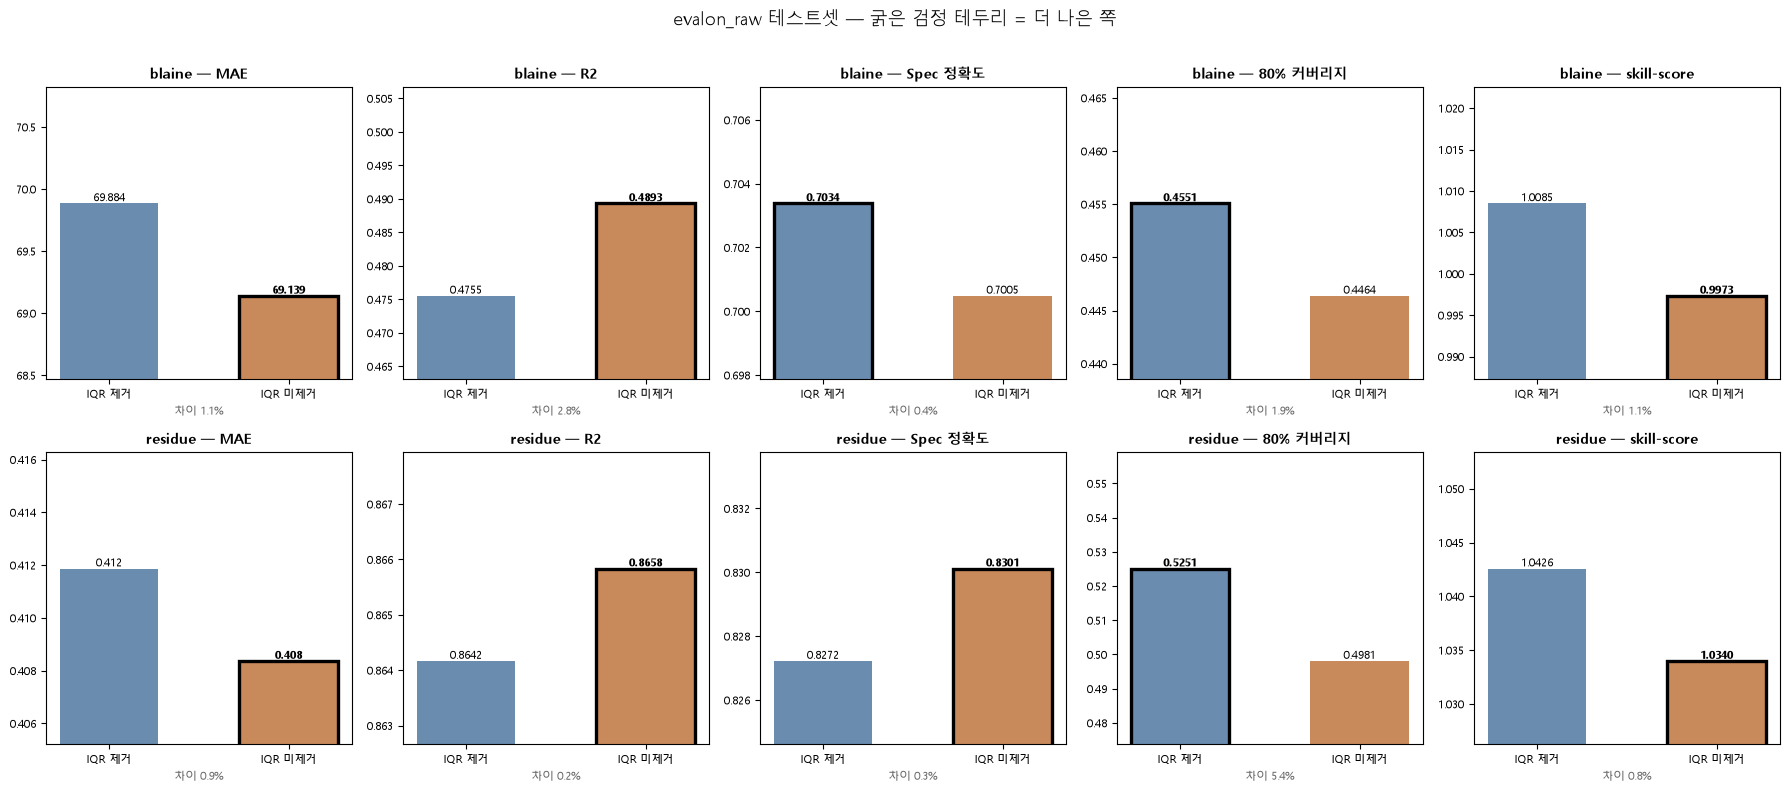

                        MAE      R2  Spec 정확도  80% 커버리지  skill-score  macro MAE
blaine  withiqr     69.8841  0.4755    0.7034    0.4551       1.0085    69.7903
        withoutiqr  69.1394  0.4893    0.7005    0.4464       0.9973    69.0372
residue withiqr      0.4119  0.8642    0.8272    0.5251       1.0426     0.4118
        withoutiqr   0.4084  0.8658    0.8301    0.4981       1.0340     0.4083


In [5]:
raw_tbl = plot_variant_comparison('raw')
if raw_tbl is not None:
    print(raw_tbl.round(4).to_string())

## 4. clean 테스트셋 (정상운전 구간)

두 모델 다 `with_iqr` 테스트셋(IQR로 극단값 제거)에서 평가.

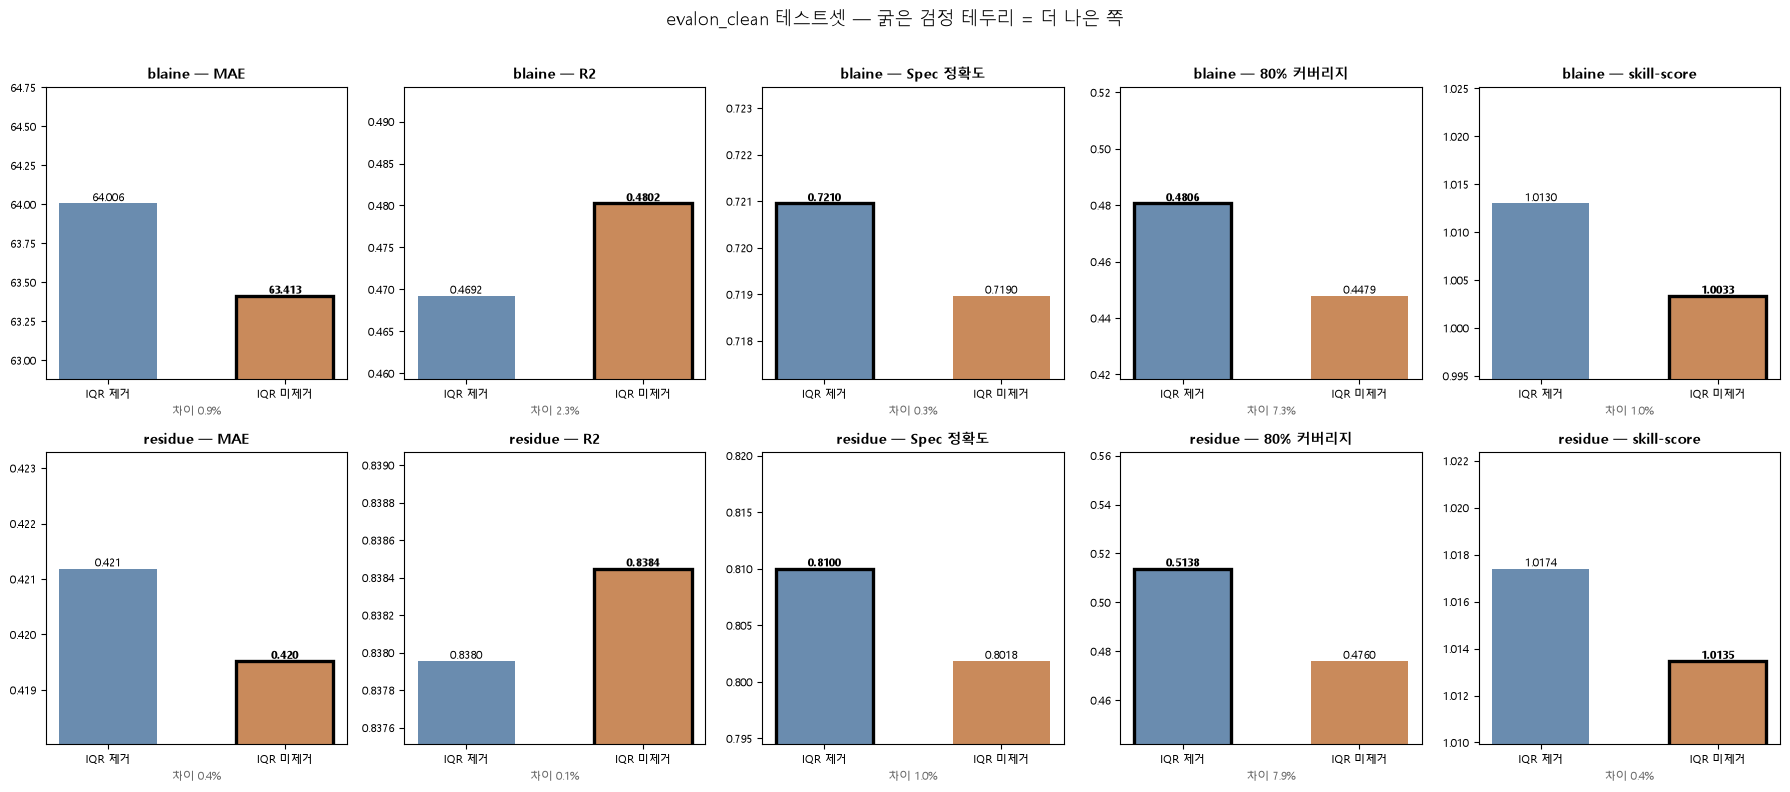

                        MAE      R2  Spec 정확도  80% 커버리지  skill-score  macro MAE
blaine  withiqr     64.0061  0.4692    0.7210    0.4806       1.0130    63.9887
        withoutiqr  63.4131  0.4802    0.7190    0.4479       1.0033    63.3931
residue withiqr      0.4212  0.8380    0.8100    0.5138       1.0174     0.4216
        withoutiqr   0.4195  0.8384    0.8018    0.4760       1.0135     0.4200


In [6]:
clean_tbl = plot_variant_comparison('clean')
if clean_tbl is not None:
    print(clean_tbl.round(4).to_string())

## 5. 요약표

In [7]:
recs = []
for target in TARGETS:
    for ev in EVAL_SETS:
        for tv in TRAIN_VARIANTS:
            if (target, tv, ev) not in bt:
                continue
            r = metric_row(bt[(target, tv, ev)], target)
            r.update({'target': target, 'eval': ev, 'train': VARIANT_LABEL[tv],
                      'n': len(bt[(target, tv, ev)])})
            recs.append(r)
if recs:
    summary = pd.DataFrame(recs).set_index(['target', 'eval', 'train'])[
        ['n', 'MAE', 'macro MAE', 'R2', 'Spec 정확도', '80% 커버리지', 'skill-score']]
    print(summary.round(4).to_string())
    # IQR 제거가 이긴 지표 수 (raw 테스트셋 기준)
    for target in TARGETS:
        if (target, 'withiqr', 'raw') in bt and (target, 'withoutiqr', 'raw') in bt:
            a = metric_row(bt[(target, 'withiqr', 'raw')], target)
            b = metric_row(bt[(target, 'withoutiqr', 'raw')], target)
            wins = sum(better_variant({'withiqr': a[m], 'withoutiqr': b[m]}, m) == 'withiqr' for m in METRICS)
            print(f'{target} (raw): IQR 제거가 이긴 지표 = {wins}/{len(METRICS)}')

                          n      MAE  macro MAE      R2  Spec 정확도  80% 커버리지  skill-score
target  eval  train                                                                     
blaine  raw   IQR 제거   1035  69.8841    69.7903  0.4755    0.7034    0.4551       1.0085
              IQR 미제거  1035  69.1394    69.0372  0.4893    0.7005    0.4464       0.9973
        clean IQR 제거   1007  64.0061    63.9887  0.4692    0.7210    0.4806       1.0130
              IQR 미제거  1007  63.4131    63.3931  0.4802    0.7190    0.4479       1.0033
residue raw   IQR 제거   1036   0.4119     0.4118  0.8642    0.8272    0.5251       1.0426
              IQR 미제거  1036   0.4084     0.4083  0.8658    0.8301    0.4981       1.0340
        clean IQR 제거    979   0.4212     0.4216  0.8380    0.8100    0.5138       1.0174
              IQR 미제거   979   0.4195     0.4200  0.8384    0.8018    0.4760       1.0135
blaine (raw): IQR 제거가 이긴 지표 = 2/5
residue (raw): IQR 제거가 이긴 지표 = 1/5


## 6. 결론 — IQR 이상치 제거는 쓰지 않는다

**raw 테스트셋(배포 현실, 주 지표) 기준, IQR 미제거가 점 예측 지표 전부에서 우세:**

| target | MAE | R² | skill-score |
|---|---|---|---|
| blaine  | 69.88 → **69.14** (-1.1%) | 0.4755 → **0.4893** | 1.0085 → **0.9973** |
| residue | 0.4119 → **0.4084** (-0.9%) | 0.8642 → **0.8658** | 1.0426 → **1.0340** |

- **blaine은 IQR 미제거로 처음 naive를 이깁니다** (skill-score 0.997 < 1.0). 이 프로젝트에서 blaine이
  naive baseline 밑으로 내려간 첫 설정입니다.
- clean 테스트셋(IQR로 정제된 정상운전 구간)에서도 결론 동일 — 자기가 학습한 분포에서조차 IQR 제거
  모델이 MAE·R²·skill-score에서 미제거에 뒤집니다.
- IQR 제거가 유일하게 근소하게 나은 건 **Spec 정확도(blaine만)·80% 커버리지** 뿐인데, 둘 다
  절대 수준이 낮아(커버리지 0.45~0.53, 목표 0.80) 의미 있는 우위로 보기 어렵습니다.

**왜 그런가:** IQR 제거는 실측 blaine/residue의 2.3%(약 940개씩) + feature 셀의 2.9%(약 11.8만 개)를
NaN으로 버립니다. Chronos-2는 NaN을 네이티브로 마스킹 처리하므로([[chronos-quality-net-nan-handling]]),
극단값을 "정리"한다고 지우면 학습 신호만 줄어드는 순손실입니다. 고정 임계값 규칙(`clean()`: 물리적으로
불가능한 값 — 댐퍼 >100%, 음압 등)은 계속 적용하되, **통계적 IQR 제거는 하지 않습니다.**

**한계:** arm당 단일 학습 run이고 차이가 ~1% 수준이라 재학습 노이즈와 겹칠 수 있음. 다만 방향이
4개 (target × 테스트셋) 조합에서 일관되게 "미제거 우세"라 신뢰도는 어느 정도 있음. 확실히 하려면
blaine(학습 ~17분)을 seed 2~3개로 재확인 권장.

**조치:** 정식 파이프라인 CSV(`data/processed/quality_timeseries.csv`)를 `build_dataset.py`의 IQR
단계 없이 재생성하거나, 학습/평가가 `without_iqr/quality_timeseries.csv`를 기본으로 읽도록 변경.